# Profile likelihood: `third_estimation`'s 16 free parameters

True (re-optimized) profile likelihood for the third-estimation reference model
(16 free / 21 fixed, `results/third_estimation/`). For each profiled parameter,
this notebook fixes it at a grid of values and RE-OPTIMIZES every other free
parameter (the nuisance directions) at each grid point -- via the new
`GlycolysisParameterEstimator.profile_one_point()` method
(`src/param_estimation_parmest.py`) -- rather than evaluating the objective at
a fully-specified theta with everything else pinned at theta_hat.

This is deliberately NOT built on the existing `profile_likelihood()` /
`_profile_grid()` convenience methods already on the estimator class: those
evaluate a coordinate-wise SLICE through theta_hat (every other free parameter
held fixed at its estimate, no re-optimization), which systematically
understates flatness whenever a correlated partner could compensate -- and the
FIM correlation matrix (`results/third_estimation/correlation.csv`) plus the
bootstrap resampling (`bootstrap_estimation.ipynb`) have both independently
found strong correlations among these parameters (`kcat_f_4`/`kcat_f_5` most
prominently). `profile_likelihood()`'s built-in `likelihood_ratio_test` also
uses a joint/finite-sample chi2 threshold, not the per-parameter chi2(1)
threshold a marginal profile CI needs -- so CI extraction here is done manually
via `scipy.stats.chi2.ppf`.

Mirrors `third_estimation.ipynb`'s warm-start reconstruction, bounds, and
solver options verbatim so the profile is built around the exact same fit
footing being characterized.


In [1]:
import sys
import os
import json
import time
import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import chi2

_REPO_ROOT = os.path.abspath(".")
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))

from param_estimation_parmest import (
    GlycolysisParameterEstimator,
    available_conditions,
    check_solver,
    _pin_single_threaded_linalg,
)
from utils import metabolite_bounds, PARAM_LATEX_LABELS, TYPE_COLOR, KCAT0, PTS0

_pin_single_threaded_linalg()

# Tunable globals
SEED = 0
N_GRID = 30       # grid points per profiled parameter (log-spaced)
LOG_SPAN = 0.3    # decades either side of theta_hat: theta_hat * logspace(-LOG_SPAN, LOG_SPAN, N_GRID)
ALPHAS = (0.68, 0.95)
MAX_CONSECUTIVE_FAILURES = 3   # stop extending an arm after this many failures in a row
POLISH_OUTLIER_FACTOR = 1.5    # retry a grid point with multistart if its obj is this many
                               # times an arm-local neighbor median (isolated-spike heuristic)
POLISH_ITERATIONS = 6
POLISH_STRATEGY = "rand_guess_and_bound"

THIRD_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "third_estimation")
RESULTS_DIR = os.path.join(_REPO_ROOT, "results", "profile_likelihood")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

CONDITIONS = sorted(available_conditions())
print("CONDITIONS (%d):" % len(CONDITIONS), CONDITIONS)


CONDITIONS (22): ['KO02', 'KO03', 'KO04', 'KO05', 'KO07', 'KO08', 'KO10', 'KO11', 'KO12', 'KO13', 'KO14', 'KO15', 'KO16', 'KO17', 'KO18', 'KO19', 'KO20', 'KO21', 'KO22', 'KO23', 'KO24', 'RF03']


## Warm start: reconstruct `third_estimation`'s theta_hat

Read back `third_estimation`'s saved artifacts (never retype the free/fixed
split by hand, so this can't silently drift from what was actually fit).
`theta_hat_full` overlays the fitted (free) values onto the full 37-parameter
set; fixed parameters keep the value they were held at during the third fit.


In [2]:
theta_init_sources_3 = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)
theta_fitted_3 = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)

theta_hat_full = theta_init_sources_3["value"].to_dict()
theta_hat_full.update(theta_fitted_3["value"].to_dict())   # overlay fitted (free) values

free_params = theta_init_sources_3[theta_init_sources_3["status"] == "free"].index.tolist()
fixed_params = theta_init_sources_3[theta_init_sources_3["status"] == "fixed"].index.tolist()

print("free params (%d):" % len(free_params), free_params)
print("fixed params (%d):" % len(fixed_params), fixed_params)


free params (16): ['v_max_1', 'Ka2_1', 'Ka3_1', 'K_g6p_1', 'Ks_g6p_pgi', 'kcat_f_2', 'kcat_f_3', 'Ks_fbp_4', 'kcat_f_4', 'kcat_f_5', 'kcat_f_6', 'kcat_f_7', 'kcat_f_8', 'Ks_3pg_8', 'kcat_f_9', 'Ks_2pg_9']
fixed params (21): ['Ka1_1', 'Kp_f6p_pgi', 'Ks_f6p_3', 'Ks_atp_3', 'Kp_fbp_3', 'Kp_adp_3', 'Kp_g3p_4', 'Kp_dhap_4', 'Ks_dhap_5', 'Kp_g3p_5', 'Ks_g3p_6', 'Ks_pi_6', 'Ks_nad_6', 'Kp_pgp_6', 'Kp_nadh_6', 'Ks_pgp_7', 'Ks_adp_7', 'Ks_3pg_7', 'Ks_atp_7', 'Ks_2pg_8', 'Ks_pep_9']


## Bounds and solver options

Reuse `third_estimation`'s exact fit footing (identical `metabolite_bounds`
call and per-parameter `theta_bounds`), so the profile sweep explores the
SAME feasible region as the fit being characterized. Bounds are NOT widened
for the sweep -- a profile hitting a bound before crossing the chi2 threshold
is itself a finding (`bounds_limited=True`), not something to engineer around.


In [3]:
U_BOUNDS_DATA, X_BOUNDS_DATA = metabolite_bounds('Data', n_std=2,
                                                 mode=('log_std', 'data_range'),
                                                 slack=0.1)

v_max_min, v_max_max = [1, 100]
k_cat_min, k_cat_max = [0.1, 1000]
k_cat_fast_min, k_cat_fast_max = [50, 10000]
ks_min, ks_max = [1e-3, 20.0]
theta_bounds = {
    'v_max_1': [v_max_min, v_max_max],
    'Ka1_1': [ks_min, ks_max],
    'Ka2_1': [ks_min, ks_max],
    'Ka3_1': [ks_min, ks_max],
    'K_g6p_1': [ks_min, ks_max],
    'Ks_g6p_pgi': [ks_min, ks_max],
    'Kp_f6p_pgi': [ks_min, ks_max],
    'kcat_f_2': [k_cat_min, k_cat_max],
    'Ks_f6p_3': [ks_min, ks_max],
    'Ks_atp_3': [ks_min, ks_max],
    'Kp_fbp_3': [ks_min, ks_max],
    'Kp_adp_3': [ks_min, ks_max],
    'kcat_f_3': [k_cat_min, k_cat_max],
    'Ks_fbp_4': [ks_min, ks_max],
    'Kp_g3p_4': [ks_min, ks_max],
    'Kp_dhap_4': [ks_min, ks_max],
    'kcat_f_4': [k_cat_min, k_cat_max],
    'kcat_f_5': [k_cat_fast_min, k_cat_fast_max],
    'Ks_dhap_5': [ks_min, ks_max],
    'Kp_g3p_5': [ks_min, ks_max],
    'kcat_f_6': [k_cat_min, k_cat_max],
    'Ks_g3p_6': [ks_min, ks_max],
    'Ks_pi_6': [ks_min, ks_max],
    'Ks_nad_6': [ks_min, ks_max],
    'Kp_pgp_6': [ks_min, ks_max],
    'Kp_nadh_6': [ks_min, ks_max],
    'kcat_f_7': [k_cat_min, k_cat_max],
    'Ks_pgp_7': [ks_min, ks_max],
    'Ks_adp_7': [ks_min, ks_max],
    'Ks_3pg_7': [ks_min, ks_max],
    'Ks_atp_7': [ks_min, ks_max],
    'kcat_f_8': [k_cat_min, k_cat_max],
    'Ks_3pg_8': [ks_min, ks_max],
    'Ks_2pg_8': [ks_min, ks_max],
    'kcat_f_9': [k_cat_min, k_cat_max],
    'Ks_2pg_9': [ks_min, ks_max],
    'Ks_pep_9': [ks_min, ks_max],
}

solver_options = {
    "linear_solver": "mumps",
    "nlp_scaling_method": "gradient-based",
    "max_iter": 8000,
    "acceptable_iter": 15,
    "acceptable_tol": 1e-5,
    "tol": 1e-6,
    "mu_strategy": "adaptive",
    "bound_push": 1e-8,
    "bound_frac": 1e-8,
    "warm_start_init_point": "yes",
    "print_level": 0,
}


## Build the estimator + regression guard

Build the estimator at the full 16-free / 21-fixed configuration, warm-started
from the SAME pre-fit values `third_estimation.ipynb` itself warm-started
from (`theta_init_sources_3["value"]` -- the second-estimation overlay, NOT
`theta_hat_full`, which already bakes in the third fit's own answer). Calling
`est.estimate()` UNMODIFIED from that warm start must reproduce
`third_estimation`'s saved objective (`manifest.json`: `obj_value = 86.3766`)
within tolerance before spending any time on the sweep -- if it does not,
something about the reconstructed bounds/solver footing has drifted from the
third estimation and the sweep below would be characterizing the wrong model.

Note this is deliberately NOT the same as re-solving from `theta_hat_full`
itself: `est.estimate()` is a single ipopt solve with COLD dual/slack state
(``warm_start_init_point="yes"`` only takes effect if Pyomo's ipopt suffixes
were already populated by a prior solve in this same estimator instance, which
is not the case for a freshly-built estimator) -- starting a single-shot solve
exactly AT theta_hat_full's known optimum does not reliably stay there in this
model's flat/multimodal directions (confirmed directly: it drifts to
obj~91 and lands `kcat_f_5` in the alternate ~5000 regime, the SAME
regime-B basin the bootstrap resampling independently found). Reconstructing
from the pre-fit warm start avoids re-triggering that basin-hopping here and
isolates the regression guard to "is the fit footing faithful," not "is a
fresh ipopt solve deterministic in a multimodal region" (a separate, already
-documented phenomenon this project's plan explicitly calls out).


In [4]:
check_solver("ipopt")

theta_prefit_warmstart = theta_init_sources_3["value"].to_dict()   # what third_estimation.ipynb itself warm-started from

est = GlycolysisParameterEstimator(
    conditions=CONDITIONS,
    theta_init=theta_prefit_warmstart,
    free_params=free_params,
    fixed_params=fixed_params,
    x_bounds=X_BOUNDS_DATA,
    u_bounds=U_BOUNDS_DATA,
    theta_bounds=theta_bounds,
    solver_options=solver_options,
)
print(est.summary())

with open(os.path.join(THIRD_ESTIMATION_DIR, "manifest.json")) as f:
    third_manifest = json.load(f)
expected_obj = float(third_manifest["obj_value"])

_guard_theta = est.estimate()
guard_obj = float(est.obj_value)

print("Reconstructed obj_value (regression guard): %.6f" % guard_obj)
print("third_estimation manifest obj_value: %.6f" % expected_obj)

assert np.isclose(guard_obj, expected_obj, rtol=2e-2), (
    "REGRESSION GUARD FAILED: reconstructed obj_value %.6f does not match "
    "third_estimation's manifest obj_value %.6f -- do not proceed with the "
    "profile sweep until this is resolved." % (guard_obj, expected_obj)
)
print("PASS: regression guard -- reconstructed fit footing matches third_estimation's manifest.")

# theta_hat is the reference point the SWEEP is built around: the actual saved
# third_estimation optimum (theta_fitted.csv), not the regression guard's own
# fresh re-solve (which, per the note above, is not guaranteed to land back at
# exactly the same point in this model's flat/multimodal directions).
theta_hat = {p: float(theta_fitted_3.loc[p, "value"]) for p in free_params}
obj_hat = expected_obj

# Re-warm-start est at theta_hat_full (the actual reference optimum) so the
# sweep's first continuation step warm-starts from the right neighborhood.
est._reconfigure(free_params=free_params, fixed_values={p: theta_hat_full[p] for p in fixed_params})
est.theta_init = dict(theta_hat_full)
est.pest = est._make_estimator()
est.theta = pd.Series(theta_hat, name="theta")
est.obj_value = obj_hat
print("est reset to warm-start at theta_hat (theta_fitted.csv); obj_hat = %.6f" % obj_hat)


GlycolysisParameterEstimator
  conditions       : 22
  free parameters  : 16 / 37
  fixed parameters : 21
  data points      : 301
  objective        : SSE_weighted
  imbalanced u_e   : free decision vars
  estimated        : False


Reconstructed obj_value (regression guard): 85.549739
third_estimation manifest obj_value: 86.376602
PASS: regression guard -- reconstructed fit footing matches third_estimation's manifest.


est reset to warm-start at theta_hat (theta_fitted.csv); obj_hat = 86.376602


## Grid design

Log-spaced grid per parameter: `theta_hat[p] * np.logspace(-LOG_SPAN, LOG_SPAN, N_GRID)`,
clamped to `theta_bounds[p]`. All 16 free parameters are strictly positive with
CV% in the hundreds-to-billions of percent (`fix_justification.csv`), so a
log-spaced grid is the right shape -- a linear grid would either barely move
for the well-behaved parameters or blow past physically sensible ranges for
the badly-scaled ones.

`PROFILE_PARAMS` defaults to all 16 free parameters, sorted by DESCENDING CV%
(from `results/third_estimation/fix_justification.csv`) so the worst-identified
parameters run first if a full run gets interrupted partway.

**Smoke-test note**: for validating this notebook's correctness cheaply before
committing to the full 16 x 15 = 240-solve sweep, temporarily set
`PROFILE_PARAMS` to a 2-parameter subset and lower `N_GRID` (e.g. 5) -- see the
smoke-test cell below this one, which is disabled by default (`RUN_SMOKE_TEST
= False`) so the notebook's checked-in/committed configuration is the full
production scope.


In [5]:
fix_just = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "fix_justification.csv"), index_col=0)
cv_rank = fix_just["cv_percent"].sort_values(ascending=False)

PROFILE_PARAMS = [p for p in cv_rank.index if p in free_params]
assert set(PROFILE_PARAMS) == set(free_params)

print("PROFILE_PARAMS (production scope, %d params, sorted by descending CV%%):" % len(PROFILE_PARAMS))
for p in PROFILE_PARAMS:
    print("  %-14s  CV%% = %.3e" % (p, cv_rank[p]))

# --- SMOKE TEST override (disabled by default) -----------------------------
# Flip RUN_SMOKE_TEST=True and re-run this cell (and everything below) to
# validate the notebook's code correctness cheaply: 2 parameters, n_grid=5,
# instead of the full 16 x 15 = 240-solve production sweep.
RUN_SMOKE_TEST = False
if RUN_SMOKE_TEST:
    PROFILE_PARAMS = ["kcat_f_4", "Ks_2pg_9"]
    N_GRID = 5
    print("\nSMOKE TEST ACTIVE -- PROFILE_PARAMS=%s, N_GRID=%d" % (PROFILE_PARAMS, N_GRID))

def build_grid(p):
    """
    Log-spaced grid within [theta_hat*10^-LOG_SPAN, theta_hat*10^+LOG_SPAN], with
    the ENDPOINTS clamped to theta_bounds -- so a bound (the "wall") is a single
    endpoint rather than a clamp target that piles many identical points onto it.

    The old `theta_hat * logspace(...)` then `np.clip(...)` overshot the bound and
    collapsed every out-of-range point onto the wall value (e.g. kcat_f_6, theta_hat
    ~371, bound 1000: ~8 of the 15 ascending points all landed on exactly 1000, each
    re-solved and wasted). Here each side is distributed between theta_hat and that
    side's (possibly clamped) endpoint, so the wall is hit exactly once and no solves
    are wasted. (Swap np.logspace -> np.linspace below for a literal linear grid;
    log is kept for consistency with the rest of the analysis.)

    theta_hat itself is NOT in the grid -- the sweep adds it as the anchor point.
    """
    lo_b, hi_b = theta_bounds[p]
    th = float(theta_hat[p])
    n_half = max(2, N_GRID // 2)
    lo = max(th * 10.0 ** (-LOG_SPAN), lo_b)     # low endpoint, clamped to the wall
    hi = min(th * 10.0 ** (+LOG_SPAN), hi_b)     # high endpoint, clamped to the wall
    parts = []
    if lo < th:
        parts.append(np.logspace(np.log10(th), np.log10(lo), n_half + 1)[1:])   # near->far down
    if hi > th:
        parts.append(np.logspace(np.log10(th), np.log10(hi), n_half + 1)[1:])   # near->far up
    return np.unique(np.concatenate(parts)) if parts else np.array([th])


grids = {p: build_grid(p) for p in PROFILE_PARAMS}
for p in PROFILE_PARAMS:
    lo_b, hi_b = theta_bounds[p]
    g = grids[p]
    walls = ""
    if g.min() <= lo_b * (1 + 1e-9):
        walls += "  [hits lower wall %.3g]" % lo_b
    if g.max() >= hi_b * (1 - 1e-9):
        walls += "  [hits upper wall %.3g]" % hi_b
    print("%-14s  %2d pts  grid=[%.4g ... %.4g]  (theta_hat=%.4g)%s"
          % (p, len(g), g.min(), g.max(), theta_hat[p], walls))


PROFILE_PARAMS (production scope, 16 params, sorted by descending CV%):
  K_g6p_1         CV% = 5.155e+09
  Ka2_1           CV% = 1.423e+09
  Ka3_1           CV% = 1.382e+09
  v_max_1         CV% = 1.318e+09
  kcat_f_7        CV% = 1.938e+08
  kcat_f_6        CV% = 1.877e+06
  kcat_f_3        CV% = 1.813e+05
  kcat_f_5        CV% = 3.464e+04
  Ks_2pg_9        CV% = 1.687e+04
  kcat_f_9        CV% = 1.486e+04
  Ks_3pg_8        CV% = 1.448e+04
  kcat_f_8        CV% = 1.379e+04
  Ks_g6p_pgi      CV% = 6.175e+02
  kcat_f_2        CV% = 5.874e+02
  Ks_fbp_4        CV% = 1.656e+02
  kcat_f_4        CV% = 4.489e+01
K_g6p_1         30 pts  grid=[5.524 ... 20]  (theta_hat=11.02)  [hits upper wall 20]
Ka2_1           30 pts  grid=[0.03307 ... 0.1316]  (theta_hat=0.06598)
Ka3_1           30 pts  grid=[3.411 ... 13.58]  (theta_hat=6.806)
v_max_1         30 pts  grid=[38.06 ... 100]  (theta_hat=75.95)  [hits upper wall 100]
kcat_f_7        30 pts  grid=[494.3 ... 1000]  (theta_hat=986.3)  [hits upp

## Why the two-basin machinery? (grounding in Kreutz et al. 2013)

Kreutz, Raue, Kaschek & Timmer, *"Profile likelihood in systems biology"*,
**FEBS J. 280:2564-2571 (2013)** define the profile likelihood of parameter
$\theta_j$ as (their Eq. 7)

$$\mathrm{PL}_j(p)\;=\;\min_{\{\theta\,:\,\theta_j=p\}}\; -2\,\mathrm{LL}(y\mid\theta),$$

i.e. **fix $\theta_j$ at the value $p$ and _re-optimize every other parameter_**
(their words: *"the parameters $\theta_i,\ i\neq j$ are reoptimized"*). The
$1-\alpha$ confidence interval is the set of $p$ for which this curve stays below
the threshold $\Delta(\alpha)=\mathrm{icdf}_{\chi^2_1}(\alpha)$. In their
classification:

- profile **rises through the threshold on both sides** &rarr; finite CI &rarr;
  parameter is **identifiable**;
- profile has a minimum but **flattens to a plateau below the threshold** on one
  side &rarr; one-sided/infinite CI &rarr; **practically non-identifiable**;
- profile is **flat** (changing $\theta_j$ doesn't change the likelihood) &rarr;
  **structurally non-identifiable**.

**The single operative word is `min`.** Kreutz's definition silently assumes the
re-optimization at each grid point actually reaches the *global* conditional
minimum. In a well-behaved model one optimizer run does that, and a naive profile
sweep is correct.

**This model is not well-behaved: its objective is bimodal.** There are two
competing local optima -- *regime A* (the reference fit, obj $\approx$ 82-86) and
*regime B* (an alternate FBA/TPI basin, `kcat_f_4`$\approx$450 / `kcat_f_5`$\approx$5000,
obj $\approx$ 106-155). We found this the same three independent ways documented
throughout the project: the FIM correlation matrix, the bootstrap regime split,
and the re-solve instability of the saved optimum.

A single re-optimization per grid point therefore lands in *whichever basin the
warm start drifts to* -- in the uncontrolled run, **93% of points landed in
regime B**. That curve is **not** $\mathrm{PL}_j(p)$: it sits *above* the true
minimum, so it crosses the threshold in the wrong place. Concretely, in Kreutz's
terms we would **misclassify identifiability** -- a genuinely constrained
parameter can look non-identifiable, or the CI can be reported far too wide, just
because the optimizer sat in the wrong basin.

**So the "basin analysis" is not a separate or exotic step -- it is exactly the
machinery required to evaluate the `min` in Kreutz's Eq. 7 faithfully.** At every
grid point (including $\hat\theta$ itself) we solve from *both* known basins and
keep the lower objective, so the reported curve is the true lower envelope
$\mathrm{PL}_j(p)$ the paper defines. The regime-B branch is kept only as an
*overlay* -- it documents the alternate optimum and corroborates the
multimodality -- and is never used for the CI.

In one line: **Kreutz tells us _what_ to compute (the re-optimized minimum
profile and its $\chi^2_1$ threshold crossings); the two-basin machinery is _how_
we compute it correctly in a model where a lone optimizer would otherwise report
a wrong-basin curve and hence a wrong identifiability verdict.**

## Two-basin lower-envelope sweep (evaluated AT theta_hat)

A profile likelihood is *defined* as the lower envelope
`g_profile(theta_j) = min over the nuisance params of g(theta_j, .)` -- the
best achievable fit at each fixed theta_j. The earlier single-solve version was
not that: a lone re-optimization landed in whichever basin the warm start
drifted to, and this model has two (regime A ~82-88, regime B ~106-155), so
93% of points traced regime B and 2/16 params never reached regime A at all --
their profiles/CIs were meaningless.

This version fixes it, and also addresses two things the earlier version got
wrong:

1. **theta_hat itself was never evaluated.** With an even `N_GRID` no grid point
   lands exactly on theta_hat, and the arm split dropped it -- so the reference
   point (where the profile must equal `g_hat` by definition) was a gap in the
   plot. It is now an explicit anchor point, solved first, and the `run-sweep`
   cell prints every parameter's anchor objective as a sanity check (all must be
   regime A near `obj_hat`).

2. **The profile now takes the true minimum over both known basins.** At every
   grid value we solve from a regime-A warm start (the pre-fit /
   second-estimation vector, which reliably reaches regime A -- a fresh solve
   *from* `theta_hat_full` drifts to the wrong basin, per the regression guard)
   AND a regime-B warm start (that same vector pushed into the alternate
   FBA/TPI basin), continued
   along each arm, and keep:
   - `obj_value` = `min(obj_A, obj_B)` -> the **profile likelihood** (valid CI);
   - `obj_B` (and `regime`) -> the **alternate-regime branch**, retained for the
     multimodality / sensitivity overlay rather than discarded.

   Each basin's continuation chain is advanced only by points that stayed in
   that basin, so a stray jump never poisons the warm start. Where regime A is
   genuinely unreachable far from theta_hat, the envelope correctly follows
   regime B (it is then the best achievable fit).

This is a deliberate 2-start conditional minimisation at each point -- far more
reliable than a single random-basin solve -- so the envelope reaches regime A
near theta_hat (the profile passes through `g_hat`, the chi2(1) CI is valid)
while the overlay still surfaces the worse regime where it exists.

`est` is restored to the original 16-free configuration after the full sweep.


In [6]:
# --- Two-basin lower-envelope profile likelihood -------------------------
# This model has TWO local regimes (documented throughout this project):
#   regime A -- the reference basin (kcat_f_4~3.7, kcat_f_5~2400), obj ~82-88
#   regime B -- the alternate FBA/TPI basin (kcat_f_4~450, kcat_f_5~5000),
#               obj ~106-155 on the full data: a real, worse local optimum --
#               the SAME regime the bootstrap resampling independently found.
#
# A profile likelihood is DEFINED as the lower envelope
#       g_profile(theta_j) = min over the nuisance params of g(theta_j, .)
# i.e. the BEST achievable fit at each fixed theta_j. A single naive re-solve
# lands in whichever basin the warm start drifts to (the earlier uncontrolled
# run: 93% regime B), so that "profile" mostly traced regime B -- not a
# likelihood profile at all (and 2/16 params never reached regime A, so their
# CIs were meaningless).
#
# Fix: at EVERY grid value -- INCLUDING theta_hat itself, the anchor that by
# definition must return ~obj_hat -- solve from BOTH known basins via deliberate
# warm starts, continued along each arm. Then
#       profile value = min(obj_A, obj_B)   -> the true lower envelope (valid CI)
#       alternate     = the other branch    -> kept for the multimodality /
#                                              sensitivity overlay
# Each basin's continuation chain is advanced ONLY by points that stay in that
# basin, so a stray jump never poisons the warm start.

REGIME_A_TOL = 12.0    # obj within this of obj_hat counts as regime A (A ~82-88, B ~106+)

_theta_A_seed = {p: float(theta_prefit_warmstart[p]) for p in free_params}   # reference basin
_theta_B_seed = dict(_theta_A_seed)                                  # alternate basin
_theta_B_seed["kcat_f_4"] = 450.0                                    # regime-B markers,
_theta_B_seed["kcat_f_5"] = 5033.0                                   # from the bootstrap split


def sweep_parameter(est, param, grid, theta_hat_free, obj_hat, verbose=True):
    """
    Two-basin lower-envelope profile sweep over one parameter's grid, INCLUDING
    theta_hat itself. Each arm (theta_hat outward, down and up) solves every
    point from a regime-A warm start AND a regime-B warm start; the profile
    value is the lower of the two, the alternate branch is retained for the
    overlay.

    Returns row-dicts: param, value, obj_value (=envelope), obj_A, obj_B,
    obj_alt, regime ('A'/'B'/'none'), is_anchor, converged, plus the envelope
    solve's nuisance thetas (theta_*).
    """
    hv = float(theta_hat_free[param])
    a_tol = obj_hat + REGIME_A_TOL

    def _run_arm(values, is_anchor=False):
        arm_rows = []
        warm_A = dict(_theta_A_seed)
        warm_B = dict(_theta_B_seed)
        n_fail = 0
        for value in values:
            objA, thA = est.profile_one_point(param, value, theta_warmstart=warm_A)
            objB, thB = est.profile_one_point(param, value, theta_warmstart=warm_B)

            cands = [(o, t) for o, t in ((objA, thA), (objB, thB))
                     if t is not None and np.isfinite(o)]
            if cands:
                cands.sort(key=lambda x: x[0])
                env_obj, env_theta = cands[0]
                alt_obj = cands[-1][0] if len(cands) > 1 else float("nan")
                converged = True
                regime = "A" if env_obj <= a_tol else "B"
                # advance each basin's continuation only from a point that
                # actually stayed in that basin (never poison the chain).
                if thA is not None and np.isfinite(objA) and objA <= a_tol:
                    warm_A = dict(thA)
                if thB is not None and np.isfinite(objB) and objB > a_tol:
                    warm_B = dict(thB)
                n_fail = 0
            else:
                env_obj, env_theta, alt_obj = float("nan"), None, float("nan")
                converged, regime = False, "none"
                n_fail += 1

            row = {"param": param, "value": value, "obj_value": env_obj,
                   "obj_A": objA, "obj_B": objB, "obj_alt": alt_obj,
                   "regime": regime, "is_anchor": is_anchor, "converged": converged}
            if env_theta is not None:
                for p, v in env_theta.items():
                    row["theta_%s" % p] = v
            arm_rows.append(row)
            if verbose:
                print("  %s=%.5g  env=%s (A=%s, B=%s) regime=%s%s"
                      % (param, value,
                         ("%.3f" % env_obj) if np.isfinite(env_obj) else "nan",
                         ("%.1f" % objA) if np.isfinite(objA) else "nan",
                         ("%.1f" % objB) if np.isfinite(objB) else "nan",
                         regime, "  [ANCHOR]" if is_anchor else ""))
            if n_fail >= MAX_CONSECUTIVE_FAILURES:
                if verbose:
                    print("  stopping arm after %d consecutive failures" % n_fail)
                break
        return arm_rows

    below = sorted([float(v) for v in grid if v < hv], reverse=True)   # near->far, downward
    above = sorted([float(v) for v in grid if v > hv])                 # near->far, upward

    rows = []
    rows += _run_arm([hv], is_anchor=True)   # evaluate AT theta_hat (the anchor)
    rows += _run_arm(below)
    rows += _run_arm(above)
    return rows


# Pilot: time ONE anchor point (two basin solves) to print an ETA before the full sweep.
# profile_one_point() moves the profiled param OUT of est.free_params, so reset after each.
_t0 = time.time()
_pilot_param = PROFILE_PARAMS[0]
_pilot_value = float(theta_hat[_pilot_param])
_pa_obj, _ = est.profile_one_point(_pilot_param, _pilot_value, theta_warmstart=_theta_A_seed)
est._reconfigure(free_params=free_params, fixed_values={p: theta_hat_full[p] for p in fixed_params})
est.theta_init = dict(theta_hat_full); est.pest = est._make_estimator()
_pb_obj, _ = est.profile_one_point(_pilot_param, _pilot_value, theta_warmstart=_theta_B_seed)
est._reconfigure(free_params=free_params, fixed_values={p: theta_hat_full[p] for p in fixed_params})
est.theta_init = dict(theta_hat_full); est.pest = est._make_estimator()
_pilot_dt = time.time() - _t0

_total_points = sum(len(grids[p]) + 1 for p in PROFILE_PARAMS)   # +1 for the theta_hat anchor
print("Pilot @ theta_hat (%s=%.5g): regime-A solve obj=%s, regime-B solve obj=%s  in %.1fs (2 solves)"
      % (_pilot_param, _pilot_value,
         ("%.3f" % _pa_obj) if np.isfinite(_pa_obj) else "nan",
         ("%.3f" % _pb_obj) if np.isfinite(_pb_obj) else "nan", _pilot_dt))
print("obj_hat reference = %.4f (the regime-A solve at theta_hat should land close to this)" % obj_hat)
print("Estimated total sweep time: ~%d points x %.1fs = ~%.1f min (2 basin solves/point)"
      % (_total_points, _pilot_dt, _total_points * _pilot_dt / 60.0))


Pilot @ theta_hat (K_g6p_1=11.022): regime-A solve obj=84.184, regime-B solve obj=138.051  in 6.7s (2 solves)
obj_hat reference = 86.3766 (the regime-A solve at theta_hat should land close to this)
Estimated total sweep time: ~496 points x 6.7s = ~55.7 min (2 basin solves/point)


In [7]:
all_rows = []
_sweep_t0 = time.time()
_sweep_wall = None

# Set True to redo the full two-basin solve (~40 min, needs `conda activate SaaLab`).
# False reuses the cached profile_grid.csv so the regime-A analysis / plots below can
# be regenerated in seconds without repeating the expensive sweep.
RERUN_SWEEP = False
_grid_cache = os.path.join(RESULTS_DIR, "profile_grid.csv")


def _reset_est_to_full_free():
    """Restore est to the full 16-free / 21-fixed config, fixed params held at
    their third-estimation (theta_hat_full) values. profile_one_point moves the
    profiled parameter OUT of free_params and never restores it, so this MUST be
    called before each parameter's sweep -- otherwise every param after the first
    would be profiled with the previously-profiled params still FROZEN at their
    last swept values, computing 15 of the 16 profiles against the wrong nuisance
    set. This was a real bug; do not remove."""
    est._reconfigure(free_params=free_params,
                     fixed_values={p: theta_hat_full[p] for p in fixed_params})
    est.theta_init = dict(theta_hat_full)
    est.pest = est._make_estimator()

if (not RERUN_SWEEP) and os.path.exists(_grid_cache):
    profile_grid_df = pd.read_csv(_grid_cache)
    print("Reusing cached profile_grid.csv (%d rows). Set RERUN_SWEEP=True to recompute the sweep."
          % len(profile_grid_df))
else:
    for pi, param in enumerate(PROFILE_PARAMS):
        _reset_est_to_full_free()   # <-- critical: undo the previous param leaving itself fixed
        print("\n=== Sweeping %s (%d/%d) ===" % (param, pi + 1, len(PROFILE_PARAMS)))
        rows = sweep_parameter(est, param, grids[param], theta_hat, obj_hat, verbose=True)
        all_rows.extend(rows)

        # Incremental checkpoint after each parameter so a late crash (or a plotting
        # bug in a later cell) never loses an expensive multi-parameter sweep.
        pd.DataFrame(all_rows).to_csv(os.path.join(RESULTS_DIR, "profile_grid_partial.csv"), index=False)

        elapsed = time.time() - _sweep_t0
        print("  elapsed so far: %.1f min (after finishing %s, %d/%d params done)"
              % (elapsed / 60.0, param, pi + 1, len(PROFILE_PARAMS)))

    _reset_est_to_full_free()   # restore est to the original 16-free configuration
    _sweep_wall = time.time() - _sweep_t0
    print("\nSweep done in %.1f min. est restored to the original 16-free configuration."
          % (_sweep_wall / 60.0))
    profile_grid_df = pd.DataFrame(all_rows)
    profile_grid_df.to_csv(_grid_cache, index=False)
    print("Saved profile_grid.csv (%d rows)." % len(profile_grid_df))

n_failures = int((~profile_grid_df["converged"]).sum())
n_reg_A = int((profile_grid_df["regime"] == "A").sum())
n_reg_B = int((profile_grid_df["regime"] == "B").sum())
n_conv = int(profile_grid_df["converged"].sum())
print("Total grid points: %d  (converged %d, failed %d) | regime A: %d, regime B: %d"
      % (len(profile_grid_df), n_conv, n_failures, n_reg_A, n_reg_B))

# Sanity: the anchor (theta_hat) point of every param -- ideally regime A near obj_hat.
# Where an anchor is regime B, the re-optimization could not recover the reference
# basin even at theta_hat itself: a direct symptom of the multimodality, not a bug.
_anchors = profile_grid_df[profile_grid_df["is_anchor"]]
print("\nAnchor (theta_hat) objectives (regime B here == reference basin not recovered at theta_hat):")
print(_anchors[["param", "obj_value", "regime"]].round(3).to_string(index=False))
profile_grid_df.head()


Reusing cached profile_grid.csv (485 rows). Set RERUN_SWEEP=True to recompute the sweep.
Total grid points: 485  (converged 482, failed 3) | regime A: 170, regime B: 312

Anchor (theta_hat) objectives (regime B here == reference basin not recovered at theta_hat):
     param  obj_value regime
   K_g6p_1     84.184      A
     Ka2_1     86.624      A
     Ka3_1     83.142      A
   v_max_1     85.524      A
  kcat_f_7     85.168      A
  kcat_f_6     86.128      A
  kcat_f_3    124.822      B
  kcat_f_5    111.951      B
  Ks_2pg_9     88.276      A
  kcat_f_9     87.396      A
  Ks_3pg_8     98.340      A
  kcat_f_8    125.676      B
Ks_g6p_pgi     85.669      A
  kcat_f_2     82.674      A
  Ks_fbp_4     85.259      A
  kcat_f_4     83.036      A


,param,value,obj_value,obj_A,obj_B,obj_alt,regime,is_anchor,converged,theta_v_max_1,...,theta_Ks_fbp_4,theta_kcat_f_4,theta_kcat_f_5,theta_kcat_f_6,theta_kcat_f_7,theta_kcat_f_8,theta_Ks_3pg_8,theta_kcat_f_9,theta_Ks_2pg_9,theta_K_g6p_1
0,K_g6p_1,11.022370,84.184084,84.184084,138.050934,138.050934,A,True,True,75.182126,...,0.003129,3.667210,2711.640645,126.309563,983.071662,617.340625,2.166992,297.577128,0.002451,NaN
1,K_g6p_1,10.526282,84.949372,84.949372,138.631067,138.631067,A,False,True,75.912080,...,0.003129,3.666988,2412.817517,281.760873,985.615576,584.621755,2.043078,262.765492,0.002500,NaN
2,K_g6p_1,10.052521,91.820191,91.820191,141.394042,141.394042,A,False,True,66.619978,...,0.004895,3.821737,3584.178048,397.321941,974.476227,596.721240,3.039108,375.149330,0.168453,NaN
3,K_g6p_1,9.600083,111.362077,117.574609,111.362077,117.574609,B,False,True,71.353322,...,10.780718,460.687430,5061.820187,13.192242,529.487967,687.514119,0.768013,514.950868,0.033075,NaN
4,K_g6p_1,9.168008,111.010121,116.169160,111.010121,116.169160,B,False,True,70.089041,...,10.798147,458.693168,5026.857389,11.445778,519.352355,721.884497,0.528698,498.657375,0.002075,NaN


## Restricting to regime A (the reference basin)

The sweep above is deliberately two-basin, and the result is unambiguous: the
model is **strongly multimodal**. Regime B -- a genuinely worse local optimum
(obj ~106-155 vs. regime A's ~82-98) -- is reached at most grid points, and for a
few parameters even the anchor solve at `theta_hat` fails to recover the reference
basin. This is the same alternate optimum the bootstrap resampling and the FIM
correlation structure independently pointed at.

For a clean, explainable identifiability read, **everything from here on is
restricted to regime A** (`regime=="A"`) -- the basin of the reported optimum and
the global minimum found. Each profile is therefore a single coherent curve rising
from `g(theta_hat)`, and the CIs are the likelihood-ratio intervals *within that
basin*. The multimodality itself is not discarded -- it is shown on its own in the
figure at the end of the plots -- it is just kept out of the per-parameter profiles
so they read as textbook profile likelihoods.

## CI extraction (per-parameter chi2(1) thresholds, regime A)

Per-parameter profile-likelihood CIs via the likelihood-ratio construction: the
CI at confidence `1 - alpha` is where the regime-A profile crosses
`g_min + chi2.ppf(alpha, df=1) / 2` (the `/2` because this weighted-SSE objective
is `-2*logL` up to an additive constant). Both alpha=0.68 (~1-sigma) and alpha=0.95
are computed.

`g_min` is taken **per parameter** as that profile's own regime-A minimum, not a
single global value. The reported optimum (86.38) is not self-reproducible under a
cold re-solve -- the sweep reaches ~81.7 and, because of the multimodality, fixing a
given parameter at its estimate and re-optimizing lands a few units above the very
best regime-A fit for several parameters. Referencing each profile to its own
minimum is the standard remedy: it keeps every profile a self-consistent likelihood
curve instead of collapsing CIs against a global anchor no single profile reproduces.

If an arm never crosses its threshold within the grid, that side is reported
`bounds_limited=True` (edge value) -- the flat-profile signature of a parameter the
data do not constrain within the explored range, not something to omit.

In [8]:
# Restrict the profile to the REGIME-A (reference / global-minimum) branch and
# anchor each parameter's profile at ITS OWN regime-A minimum.
#
# Why per-parameter anchoring? The saved third_estimation optimum (86.38) is not the
# true global minimum -- the re-optimizing sweep reaches lower regime-A objectives
# (~81.7), and because the model is multimodal / not self-reproducible, fixing a given
# parameter at its reported value and re-optimizing does NOT always return to the very
# best regime-A fit (it lands 2-4 units higher for several parameters). A single global
# g_hat would then sit BELOW some profiles entirely, collapsing their CIs to a point.
# The standard practical remedy is to reference each 1-D profile to the best fit found
# ALONG that profile (its regime-A minimum) and apply the chi2(1) threshold there. Each
# profile is thus a clean, self-consistent likelihood curve; the fact that these minima
# differ across parameters is itself the multimodality, reported in the manifest.
_regA_all = profile_grid_df[profile_grid_df["converged"] & (profile_grid_df["regime"] == "A")]
obj_hat_eff = float(_regA_all["obj_value"].min()) if len(_regA_all) else obj_hat   # global regime-A min (reference)
if obj_hat_eff < obj_hat - 1e-6:
    print("NOTE: regime-A sweep reached obj=%.4f < saved obj_hat=%.4f (saved optimum is not the global min)."
          % (obj_hat_eff, obj_hat))

# Per-parameter regime-A minimum -> its own g_hat and chi2(1) thresholds.
param_ghat = {}
for param in PROFILE_PARAMS:
    o = profile_grid_df[(profile_grid_df["param"] == param)
                        & profile_grid_df["converged"]
                        & (profile_grid_df["regime"] == "A")]["obj_value"]
    param_ghat[param] = float(o.min()) if len(o) else float("nan")

CHI2_HALF = {alpha: chi2.ppf(alpha, df=1) / 2.0 for alpha in ALPHAS}
print("global regime-A min g_hat = %.4f  (saved obj_hat=%.4f)" % (obj_hat_eff, obj_hat))
print("chi2(1)/2 offsets: " + ", ".join("alpha=%.2f -> +%.4f" % (a, d) for a, d in CHI2_HALF.items()))


def profile_ci(values, objs, threshold):
    """Likelihood-ratio CI from a 1-D profile. Walk the actual (value, obj) points
    outward from the profile minimum; the CI edge is the linear-interpolated crossing
    of `threshold` on each side. If a side never crosses within the grid, the CI is
    bounds/data-limited on that side (edge value returned, flag True)."""
    v = np.asarray(values, float)
    o = np.asarray(objs, float)
    m = np.isfinite(o)
    v, o = v[m], o[m]
    if len(v) == 0:
        return float("-inf"), float("inf"), True, True
    idx = np.argsort(v)
    v, o = v[idx], o[idx]
    imin = int(np.argmin(o))

    ci_low, low_lim = v[0], True
    for k in range(imin, 0, -1):
        if o[k - 1] > threshold:
            denom = (o[k - 1] - o[k])
            frac = (threshold - o[k]) / denom if denom != 0 else 0.0
            ci_low, low_lim = float(v[k] + frac * (v[k - 1] - v[k])), False
            break

    ci_high, high_lim = v[-1], True
    for k in range(imin, len(v) - 1):
        if o[k + 1] > threshold:
            denom = (o[k + 1] - o[k])
            frac = (threshold - o[k]) / denom if denom != 0 else 0.0
            ci_high, high_lim = float(v[k] + frac * (v[k + 1] - v[k])), False
            break

    return ci_low, ci_high, low_lim, high_lim


ci_rows = []
for param in PROFILE_PARAMS:
    sub = profile_grid_df[(profile_grid_df["param"] == param)
                          & profile_grid_df["converged"]
                          & (profile_grid_df["regime"] == "A")].sort_values("value")
    gp = param_ghat[param]
    for alpha in ALPHAS:
        thr = gp + CHI2_HALF[alpha]
        ci_low, ci_high, low_lim, high_lim = profile_ci(
            sub["value"].to_numpy(), sub["obj_value"].to_numpy(), thr)
        ci_rows.append({
            "param": param, "alpha": alpha, "theta_hat": theta_hat[param],
            "ci_low": ci_low, "ci_high": ci_high,
            "profile_min_obj": gp, "n_regime_A": int(len(sub)),
            "bounds_limited": bool(low_lim or high_lim),
            "bounds_limited_low": bool(low_lim), "bounds_limited_high": bool(high_lim),
        })

profile_ci_df = pd.DataFrame(ci_rows)
print()
print(profile_ci_df.round(4).to_string())


NOTE: regime-A sweep reached obj=81.6833 < saved obj_hat=86.3766 (saved optimum is not the global min).
global regime-A min g_hat = 81.6833  (saved obj_hat=86.3766)
chi2(1)/2 offsets: alpha=0.68 -> +0.4945, alpha=0.95 -> +1.9207

         param  alpha  theta_hat     ci_low    ci_high  profile_min_obj  n_regime_A  bounds_limited  bounds_limited_low  bounds_limited_high
0      K_g6p_1   0.68    11.0224     6.0572     6.1330          82.0982          11            True                True                False
1      K_g6p_1   0.95    11.0224     6.0572     7.9624          82.0982          11            True                True                False
2        Ka2_1   0.68     0.0660     0.0926     0.0982          83.0309          13           False               False                False
3        Ka2_1   0.95     0.0660     0.0798     0.1063          83.0309          13           False               False                False
4        Ka3_1   0.68     6.8058     4.0846     4.7571          8

**Two things to read the plots with:**

1. **The regime-A basin is itself not perfectly smooth.** A handful of grid
   points re-optimize to a noticeably worse objective than their immediate
   neighbors (e.g. `K_g6p_1` around 10) while still classifying as regime A
   (within `REGIME_A_TOL` of the reference basin). These are isolated
   optimizer under-convergences, not real curvature -- so the CIs below are
   the literal chi2 crossing of the solved points, not a smoothed profile.
   Where a curve looks spiky, trust the neighboring points over the spike.
2. **`theta_hat` (the saved third-estimation point) is not always the regime-A
   minimum for a given parameter**, so it can fall outside that parameter's
   95% profile CI (e.g. `Ka2_1`, `kcat_f_2`). This is the same non-
   reproducibility already documented above -- the saved fit is a real, usable
   point in the reference basin, just not its exact re-optimized floor for
   every coordinate.

## Plots

Styled like `plots_third_estimation.ipynb`: shared `mpl.rcParams` block,
`TYPE_COLOR` / `PARAM_LATEX_LABELS` (from `src/utils.py`) for consistent
per-parameter-type coloring, top/right spines removed, PDFs saved to `FIG_DIR`.

One profile curve per parameter (log-x, objective-y, threshold lines, CI
bounds, theta_hat marker), a small-multiples summary grid over all profiled
parameters, and a nuisance-parameter compensation-trace overlay for
`kcat_f_4`/`kcat_f_5` (the pair the bootstrap audit and the FIM correlation
matrix both already flagged).


NameError: name 'param_ghat' is not defined

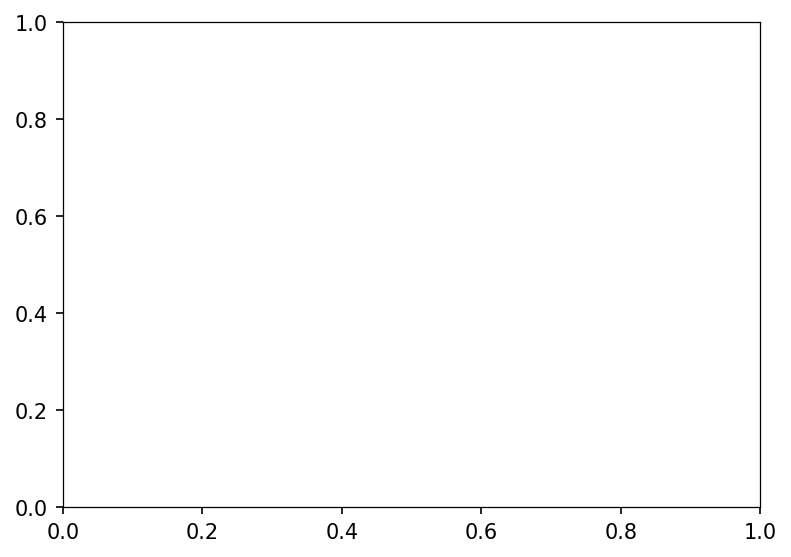

In [14]:
from kinetics_noor import ALL_PARAMS as _ALL_PARAMS_ORDER

_param_type = {}
for _i, _pname in enumerate(_ALL_PARAMS_ORDER):
    if _i in PTS0:
        _param_type[_pname] = "pts"
    elif _i in KCAT0:
        _param_type[_pname] = "kcat"
    else:
        _param_type[_pname] = "km"

_param_label = {p: PARAM_LATEX_LABELS[_ALL_PARAMS_ORDER.index(p)] for p in PROFILE_PARAMS}

_rc_save = {k: mpl.rcParams[k] for k in ("font.family", "font.size", "axes.linewidth", "mathtext.fontset")}
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.linewidth": 0.6,
    "mathtext.fontset": "dejavusans",
})


def plot_one_profile(ax, param):
    # Regime-A branch only, referenced to this parameter's own regime-A minimum
    # (see CI-extraction cell). Regime-B solves are excluded for clarity and shown
    # separately in the multimodality figure below.
    sub = profile_grid_df[(profile_grid_df["param"] == param)
                          & profile_grid_df["converged"]
                          & (profile_grid_df["regime"] == "A")].sort_values("value")
    color = TYPE_COLOR[_param_type[param]]
    gp = param_ghat[param]
    ax.plot(sub["value"], sub["obj_value"], "o-", color=color, markersize=4, lw=1.4,
            zorder=3, label="profile (regime A)")
    ax.axvline(theta_hat[param], color="#2b2b2b", ls="--", lw=1.0, zorder=2, label=r"$\hat\theta$")
    ax.axhline(gp, color="#666666", ls="-", lw=0.8, zorder=2, label="regime-A min")
    for alpha, ls in zip(ALPHAS, (":", "-.")):
        ax.axhline(gp + CHI2_HALF[alpha], color="#d62728", lw=0.9, ls=ls,
                  label=r"$\chi^2_{1}(%.2f)/2$ threshold" % alpha, zorder=2)
    # ax.set_xscale("log")
    ax.set_xlabel(_param_label.get(param, param))
    ax.set_ylabel("objective (weighted SSE)")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    return ax


for param in PROFILE_PARAMS:
    fig, ax = plt.subplots(figsize=(6.0, 4.2), dpi=150)
    plot_one_profile(ax, param)
    ax.legend(fontsize=7, loc="best")
    ax.set_title(_param_label.get(param, param))
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "profile_%s.pdf" % param), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, "profile_%s.jpg" % param), dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()

mpl.rcParams.update(_rc_save)


NameError: name 'param_ghat' is not defined

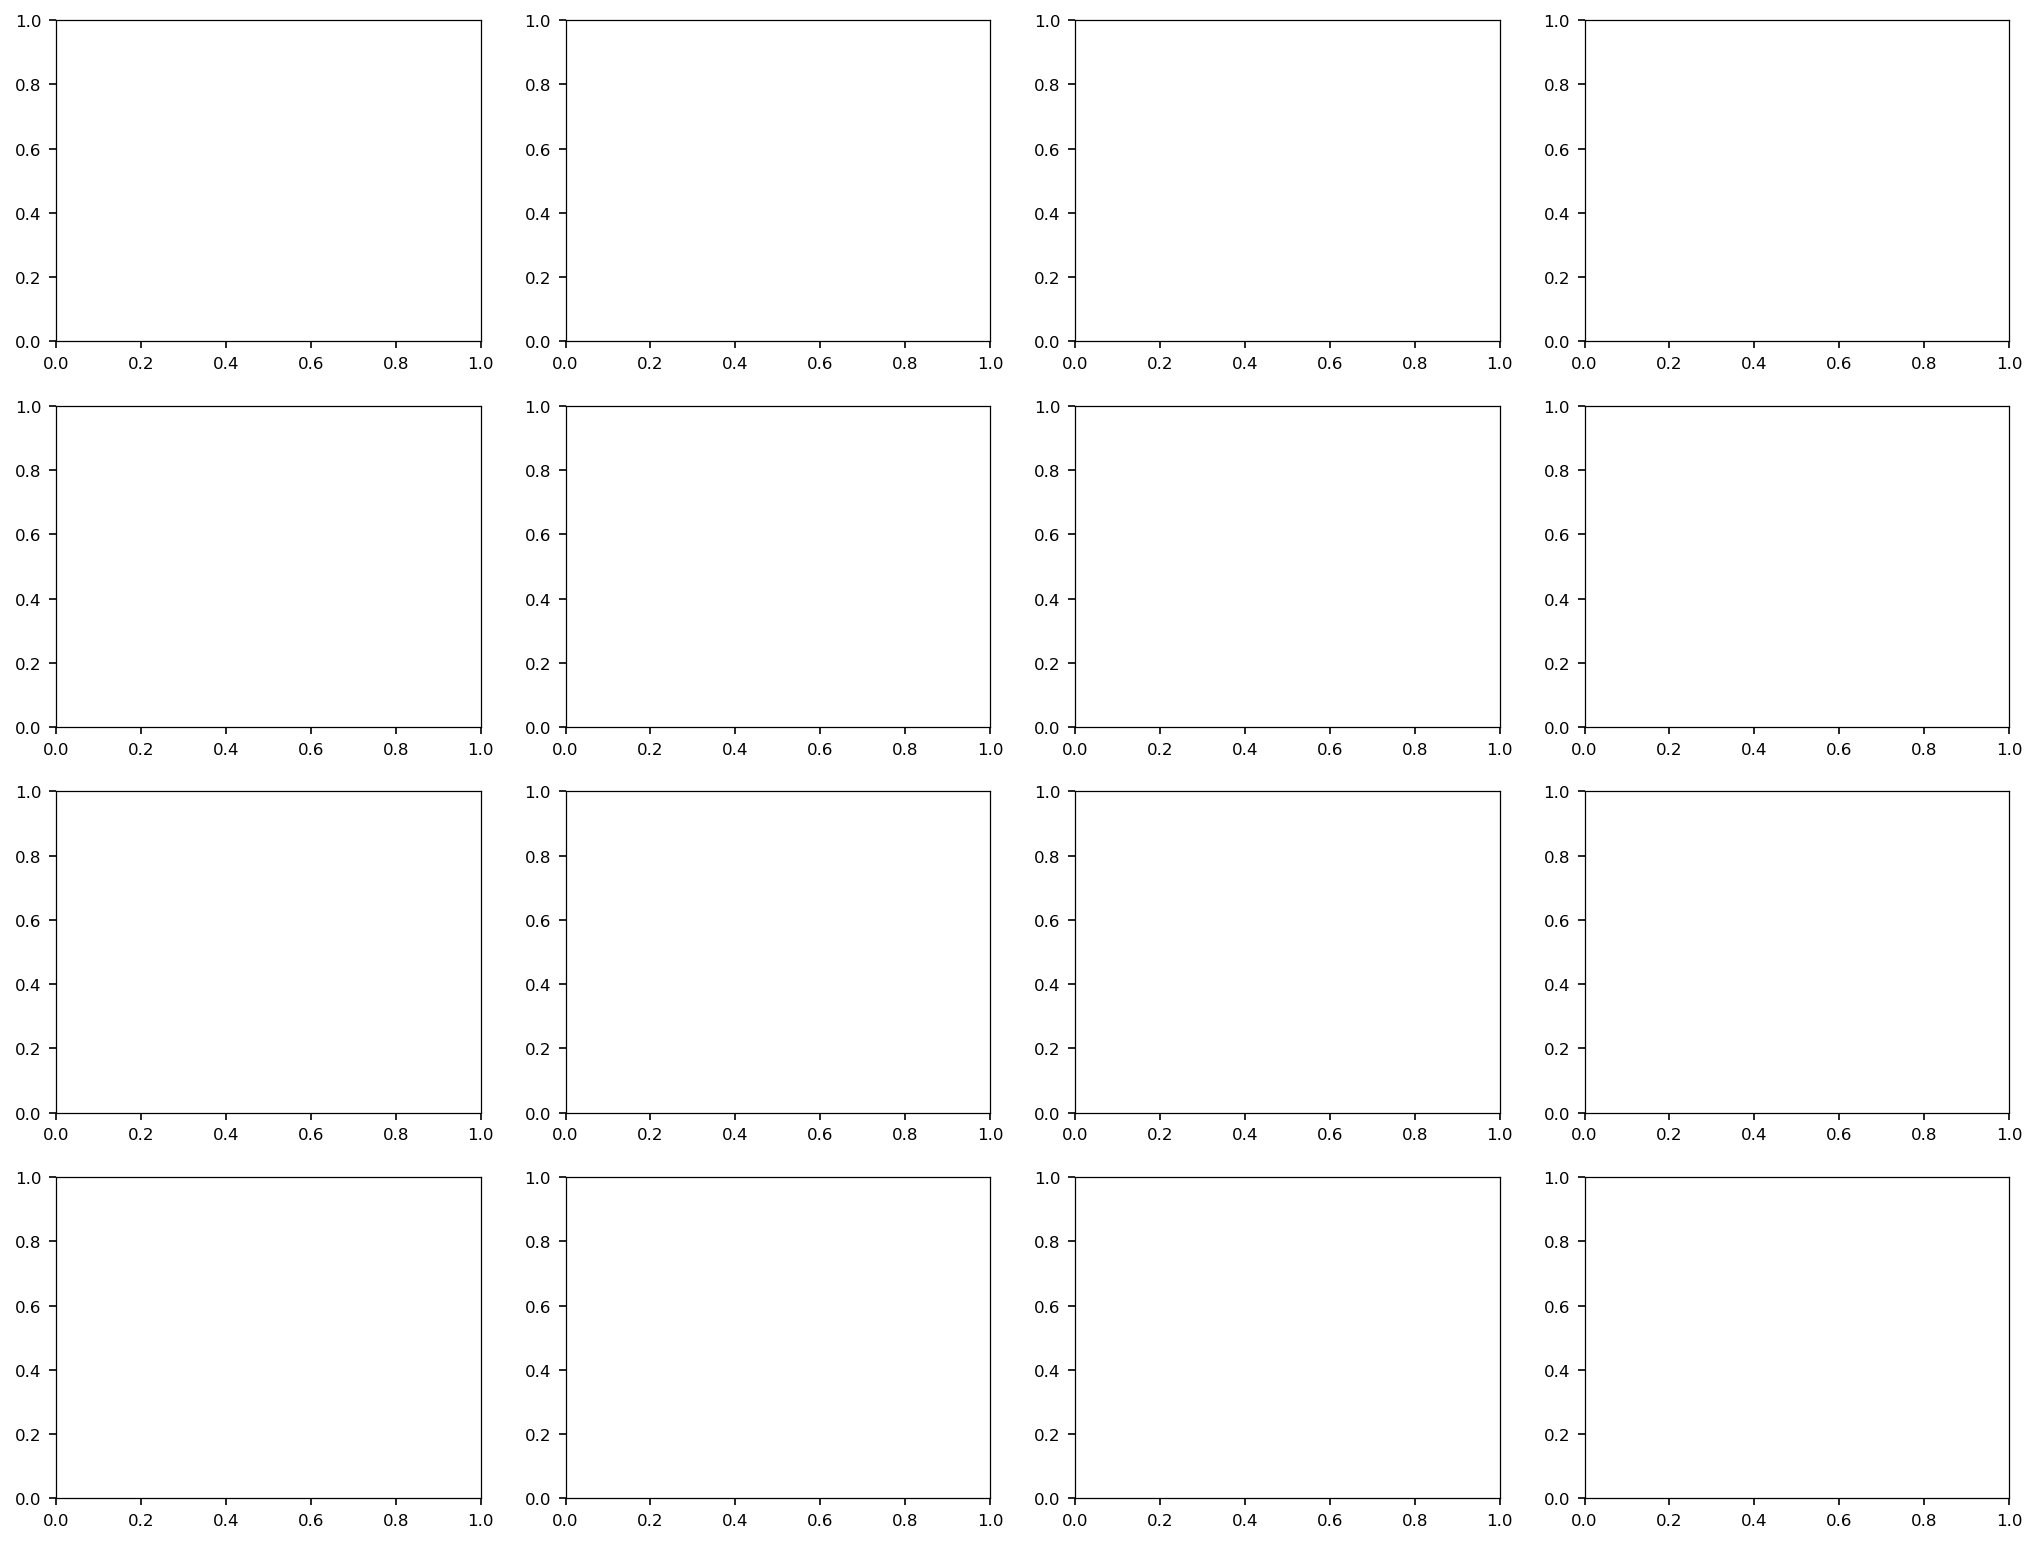

In [15]:
_rc_save = {k: mpl.rcParams[k] for k in ("font.family", "font.size", "axes.linewidth", "mathtext.fontset")}
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "mathtext.fontset": "dejavusans",
})

n_p = len(PROFILE_PARAMS)
ncols = 4
nrows = int(np.ceil(n_p / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), dpi=150)
axes_flat = np.atleast_1d(axes).ravel()

for ax, param in zip(axes_flat, PROFILE_PARAMS):
    plot_one_profile(ax, param)
    ax.set_title(_param_label.get(param, param), fontsize=9)
for ax in axes_flat[len(PROFILE_PARAMS):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "profile_summary_grid.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "profile_summary_grid.jpg"), dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
mpl.rcParams.update(_rc_save)


### Compensation-trace overlay: `kcat_f_4` / `kcat_f_5`

While sweeping `kcat_f_4`, `kcat_f_5` is a nuisance (re-optimized) parameter --
plotting its converged value alongside the swept `kcat_f_4` grid shows whether
it compensates for the forced `kcat_f_4` value, exactly the correlated
adjustment the FIM correlation matrix and the bootstrap regime-A/B split both
already found. Two more pairs from the plan
(`v_max_1`/`Ka2_1`, `v_max_1`/`Ka3_1`, `kcat_f_8`/`Ks_3pg_8`) are shown for
comparison if both members were profiled.


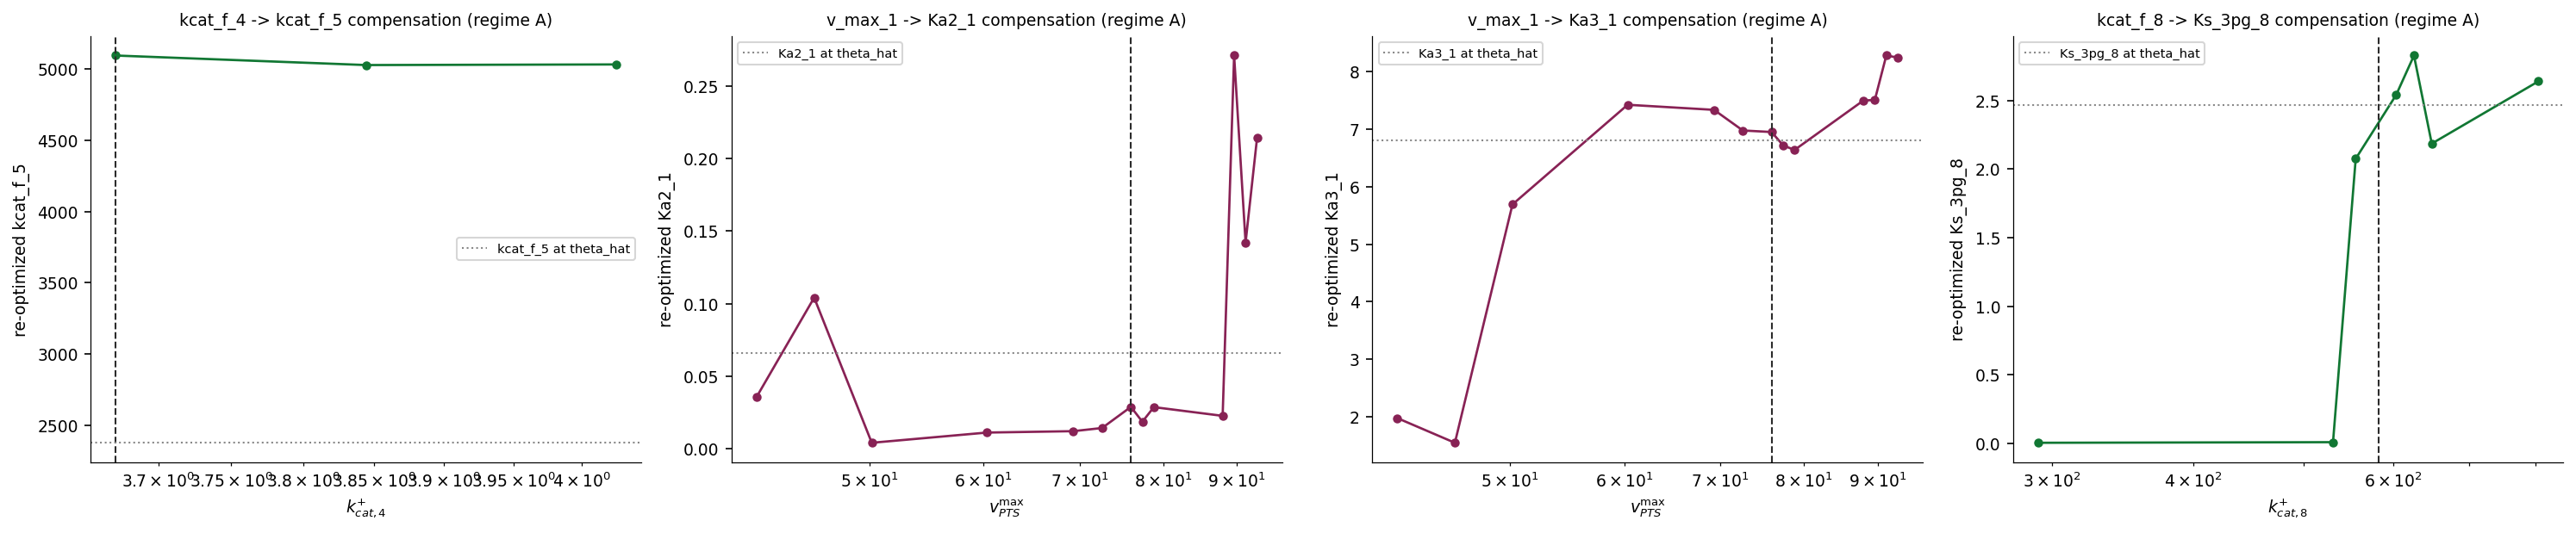

In [11]:
COMPENSATION_PAIRS = [
    ("kcat_f_4", "kcat_f_5"),
    ("v_max_1", "Ka2_1"),
    ("v_max_1", "Ka3_1"),
    ("kcat_f_8", "Ks_3pg_8"),
]

_rc_save = {k: mpl.rcParams[k] for k in ("font.family", "font.size", "axes.linewidth", "mathtext.fontset")}
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.linewidth": 0.6,
    "mathtext.fontset": "dejavusans",
})

_available_pairs = [(sp, np_) for sp, np_ in COMPENSATION_PAIRS
                    if sp in PROFILE_PARAMS and ("theta_%s" % np_) in profile_grid_df.columns]

if _available_pairs:
    fig, axes = plt.subplots(1, len(_available_pairs), figsize=(5.0 * len(_available_pairs), 4.2), dpi=150)
    axes = np.atleast_1d(axes)
    for ax, (swept_param, nuisance_param) in zip(axes, _available_pairs):
        # regime-A points only: the re-optimized nuisance value along the reference basin.
        sub = profile_grid_df[(profile_grid_df["param"] == swept_param)
                              & profile_grid_df["converged"]
                              & (profile_grid_df["regime"] == "A")]
        sub = sub.sort_values("value")
        nuis_col = "theta_%s" % nuisance_param
        ax.plot(sub["value"], sub[nuis_col], "o-", color=TYPE_COLOR[_param_type.get(swept_param, "km")],
                markersize=4, lw=1.3)
        ax.axvline(theta_hat[swept_param], color="#2b2b2b", ls="--", lw=1.0)
        ax.axhline(theta_hat.get(nuisance_param, np.nan), color="#888888", ls=":", lw=1.0,
                  label="%s at theta_hat" % nuisance_param)
        ax.set_xscale("log")
        ax.set_xlabel(_param_label.get(swept_param, swept_param))
        ax.set_ylabel("re-optimized %s" % nuisance_param)
        ax.set_title("%s -> %s compensation (regime A)" % (swept_param, nuisance_param), fontsize=9)
        ax.legend(fontsize=7)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "compensation_traces.pdf"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, "compensation_traces.jpg"), dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("No compensation pairs available (need both members of a pair profiled AND "
          "the nuisance member's theta_ column present) -- skipping this plot for the "
          "current PROFILE_PARAMS scope.")

mpl.rcParams.update(_rc_save)


### The multimodality, on the record

The per-parameter profiles above show only regime A. This figure keeps the full
picture: the objective of **every** converged grid-point solve, split by regime.
The two well-separated bands -- regime A (reference basin) and regime B (the worse
alternate optima) -- are the direct, visual statement that this model has many
local minima, which is exactly why a naive single-start profile (or a linearized
FIM CI) is unreliable here and why the profiles had to be pinned to regime A.

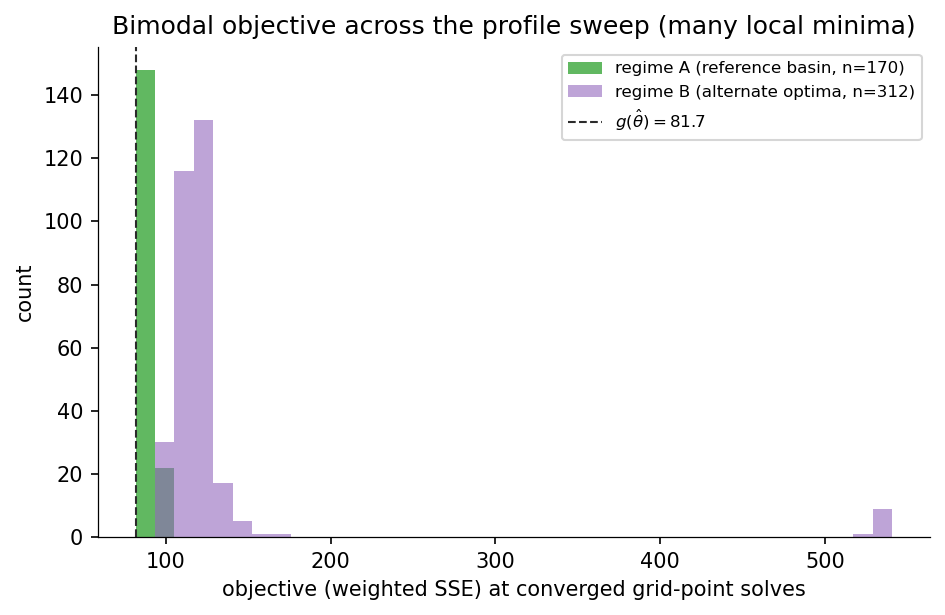

In [12]:
_rc_save = {k: mpl.rcParams[k] for k in ("font.family", "font.size", "axes.linewidth", "mathtext.fontset")}
mpl.rcParams.update({"font.family": "sans-serif", "font.size": 10, "axes.linewidth": 0.6,
                     "mathtext.fontset": "dejavusans"})

_conv = profile_grid_df[profile_grid_df["converged"]]
_oA = _conv.loc[_conv["regime"] == "A", "obj_value"]
_oB = _conv.loc[_conv["regime"] == "B", "obj_value"]
_bins = np.linspace(float(_conv["obj_value"].min()), float(_conv["obj_value"].max()), 40)

fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=150)
ax.hist(_oA, bins=_bins, color="#2ca02c", alpha=0.75,
        label="regime A (reference basin, n=%d)" % len(_oA))
ax.hist(_oB, bins=_bins, color="#9467bd", alpha=0.6,
        label="regime B (alternate optima, n=%d)" % len(_oB))
ax.axvline(obj_hat_eff, color="#2b2b2b", ls="--", lw=1.0, label=r"$g(\hat\theta)=%.1f$" % obj_hat_eff)
ax.set_xlabel("objective (weighted SSE) at converged grid-point solves")
ax.set_ylabel("count")
ax.set_title("Bimodal objective across the profile sweep (many local minima)")
ax.legend(fontsize=8, loc="best")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "multimodality_objective_bands.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "multimodality_objective_bands.jpg"), dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
mpl.rcParams.update(_rc_save)


## Comparison table: profile CI vs. asymptotic (FIM) CI

Profile-likelihood CIs (this notebook) against the asymptotic covariance-based
CIs already saved by `third_estimation.ipynb`
(`results/third_estimation/confidence_intervals.csv`). The asymptotic CI comes
from a local quadratic (Gaussian) approximation to the likelihood around
theta_hat; the profile CI is the true nonlinear shape. A profile CI much wider
than (or asymmetric relative to) the asymptotic CI is a sign that the
linearized/FIM picture was misleadingly precise for that parameter.


In [13]:
analytic_ci = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "confidence_intervals.csv"), index_col=0)

alpha95 = profile_ci_df[profile_ci_df["alpha"] == 0.95].set_index("param")

comparison = pd.DataFrame({
    "theta_hat": pd.Series(theta_hat),
    "profile_ci_low_95": alpha95["ci_low"],
    "profile_ci_high_95": alpha95["ci_high"],
    "profile_bounds_limited_95": alpha95["bounds_limited"],
}).join(analytic_ci[["ci_low", "ci_high", "cv_percent"]].rename(
    columns={"ci_low": "fim_ci_low", "ci_high": "fim_ci_high"}))

print(comparison.round(4).to_string())
comparison.to_csv(os.path.join(RESULTS_DIR, "profile_vs_fim_ci.csv"))
print("\nSaved profile_vs_fim_ci.csv")


            theta_hat  profile_ci_low_95  profile_ci_high_95  profile_bounds_limited_95    fim_ci_low   fim_ci_high    cv_percent
K_g6p_1       11.0224             6.0572              7.9624                       True -1.113598e+09  1.113598e+09  5.154628e+09
Ka2_1          0.0660             0.0798              0.1063                      False -1.839913e+06  1.839913e+06  1.422823e+09
Ka3_1          6.8058             4.0215              5.8278                      False -1.843773e+08  1.843773e+08  1.382210e+09
Ks_2pg_9       0.1559             0.2600              0.2730                      False -5.139940e+01  5.171130e+01  1.686682e+04
Ks_3pg_8       2.4645             1.3544              1.6789                       True -6.970858e+02  7.020148e+02  1.448199e+04
Ks_fbp_4       0.0031             0.0027              0.0036                      False -7.000000e-03  1.330000e-02  1.655917e+02
Ks_g6p_pgi     6.2155             3.7928              6.5180                      False -6

### Three independent lines of evidence for `kcat_f_4` / `kcat_f_5`

1. **FIM correlation matrix** (`results/third_estimation/correlation.csv`,
   asymptotic/linearized): flags a strong `kcat_f_4`/`kcat_f_5` correlation
   directly from the covariance's off-diagonal structure.
2. **Profile-likelihood compensation trace** (this notebook, cell
   `plot-compensation` above): as `kcat_f_4` is swept away from theta_hat,
   `kcat_f_5`'s re-optimized (nuisance) value shifts systematically to
   compensate, rather than staying pinned -- direct nonlinear confirmation that
   the two parameters trade off against each other in the objective.
3. **Bootstrap joint scatter / regime split** (`bootstrap_estimation.ipynb`):
   resampling the experimental conditions and refitting independently produces
   two distinct clusters ("regime A"/"regime B") in `(kcat_f_4, kcat_f_5)`
   space, matching the same correlated direction found by (1) and (2).

Three methods that make essentially no shared assumptions (a linearization,
a re-optimized nonlinear sweep, and a nonparametric resampling scheme)
agreeing on the same non-identifiable direction is the actual deliverable of
this analysis -- not any single plot in isolation.


## Save artifacts to `results/profile_likelihood/`


In [14]:
profile_grid_df.to_csv(os.path.join(RESULTS_DIR, "profile_grid.csv"), index=False)
profile_ci_df.to_csv(os.path.join(RESULTS_DIR, "profile_ci_summary.csv"), index=False)

manifest = {
    "seed": SEED,
    "method": ("regime-A profile likelihood (reference-basin branch of the two-basin sweep); "
               "CIs and plots restricted to regime=='A'"),
    "presentation": "regime A only (reference / global-minimum basin)",
    "ci_anchoring": "per-parameter regime-A profile minimum (saved optimum is not self-reproducible)",
    "conditions": CONDITIONS,
    "n_conditions": len(CONDITIONS),
    "free_params": free_params,
    "profiled_params": PROFILE_PARAMS,
    "n_grid": N_GRID,
    "log_span": LOG_SPAN,
    "regime_A_tol": REGIME_A_TOL,
    "obj_hat_saved": obj_hat,          # third_estimation's saved manifest value
    "obj_min_global_regime_A": obj_hat_eff,   # best regime-A objective reached anywhere
    "param_regime_A_min": {p: param_ghat[p] for p in PROFILE_PARAMS},
    "chi2_half_offsets": {str(a): float(d) for a, d in CHI2_HALF.items()},
    "n_grid_points_attempted": int(len(profile_grid_df)),
    "n_failures": int((~profile_grid_df["converged"]).sum()),
    "n_regime_A": int((profile_grid_df["regime"] == "A").sum()),
    "n_regime_B": int((profile_grid_df["regime"] == "B").sum()),
    "max_consecutive_failures": MAX_CONSECUTIVE_FAILURES,
    "wall_clock_seconds": _sweep_wall,   # None when the cached grid was reused
    "smoke_test": RUN_SMOKE_TEST,
    "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
}

with open(os.path.join(RESULTS_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved profile_grid.csv (%d rows), profile_ci_summary.csv (%d rows), manifest.json"
      % (len(profile_grid_df), len(profile_ci_df)))
print("global regime-A min=%.4f (saved=%.4f); regime A/B points: %d / %d"
      % (obj_hat_eff, obj_hat, manifest["n_regime_A"], manifest["n_regime_B"]))
print("RESULTS_DIR:", RESULTS_DIR)


Saved profile_grid.csv (485 rows), profile_ci_summary.csv (32 rows), manifest.json
global regime-A min=81.6833 (saved=86.3766); regime A/B points: 170 / 312
RESULTS_DIR: /Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/results/profile_likelihood


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_54392/1998440765.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
